## Name : Rehman Ahmad
## Roll No : 2024-csr-019

# 4 EDA – Step-by-Step

## 4.1 Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split

In [3]:
from sklearn.linear_model import LinearRegression

In [4]:
from sklearn.ensemble import RandomForestClassifier

In [5]:
from sklearn.preprocessing import LabelEncoder

In [6]:
from sklearn.metrics import r2_score , accuracy_score , confusion_matrix

# ✅ Understanding Key Metrics in Scikit-Learn

> This is a single line of code importing three different metrics. Let's break down each one separately.

```python
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix
````

---

## 1️⃣ **r2_score**

* **What is it?**
  A metric to measure **regression model performance**.
  R² (R-squared) tells you how much of the **variance** in the target variable is explained by the model.

  * `1.0` → perfect fit
  * `0.0` → model predicts only the mean
  * Negative → model is very poor

* **Why use it?**
  When predicting **continuous values** like house prices or numerical scores.
  Example: After fitting a `LinearRegression` model, check `R²`.

* **When to use?**
  Only for **regression problems**.
  To understand the model’s **explanatory power**.

* **Note:**
  `model.score(X_test, y_test)` automatically gives R², but `r2_score(y_true, y_pred)` allows scoring **custom predictions**.

---

## 2️⃣ **accuracy_score**

* **What is it?**
  A metric for **classification models**.
  It tells what percentage of predictions were correct.
  Example: 85 correct predictions out of 100 → `accuracy = 0.85`

* **Why use it?**
  When predicting **categories**, e.g.,

  * "High Price" vs "Low Price"
  * "Spam" vs "Not Spam"

* **When to use?**
  Only for **classification problems**.
  When classes are **approximately balanced**.

* **⚠️ Warning:**
  If the data is **imbalanced** (e.g., 95% "No", 5% "Yes"), accuracy can be misleading — use **precision, recall, F1-score** instead.

---

## 3️⃣ **confusion_matrix**

* **What is it?**
  A table showing **how often predictions matched actuals**.
  Example for binary classification:

|                 | Predicted: No | Predicted: Yes |
| --------------- | ------------- | -------------- |
| **Actual: No**  | 90 (TN)       | 5 (FP)         |
| **Actual: Yes** | 3 (FN)        | 2 (TP)         |

* **Definitions**:

  * TN = True Negative
  * FP = False Positive
  * FN = False Negative
  * TP = True Positive

* **Why use it?**
  When you need **more detail than accuracy**.
  Example: In medical tests, a **False Negative** can be dangerous — accuracy alone cannot capture this.

* **When to use?**

  * To analyze **types of errors**.
  * When calculating advanced metrics like **precision, recall, specificity**.
  * Especially useful in **critical applications** (health, finance, security).

---

## 🔍 **Summary: When to Use Each Metric**

| Metric             | Type           | When to Use                                                              |
| ------------------ | -------------- | ------------------------------------------------------------------------ |
| `r2_score`         | Regression     | When predicting **numerical values** (e.g., house prices)                |
| `accuracy_score`   | Classification | When you have **balanced data** and just need **correct/incorrect** info |
| `confusion_matrix` | Classification | When you need **detailed error analysis** (FP, FN)                       |

---

💡 **Extra Note:**
All three functions are in `sklearn.metrics` — because they are tools for **measuring model performance**.
You can import them individually, but importing together keeps your code **clean and organized**.



## 4.2 Load the Dataset
Make sure Entities.csv is in the same folder as your notebook. 

In [26]:
df = pd.read_csv("Entities.csv")
df

,Unnamed: 0,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,purpose,bedrooms,date_added,agency,agent,Total_Area
0,0,237062,3325,https://www.zameen.com/Property/g_10_g_10_2_gr...,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,For Sale,2,2/4/2019,NaN,NaN,1089.004
1,1,346905,3236,https://www.zameen.com/Property/e_11_2_service...,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,For Sale,3,5/4/2019,NaN,NaN,15246.056
2,2,386513,764,https://www.zameen.com/Property/islamabad_g_15...,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,For Sale,5,7/17/2019,NaN,NaN,2178.008
3,3,656161,340,https://www.zameen.com/Property/islamabad_bani...,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,For Sale,4,4/5/2019,NaN,NaN,10890.000
4,4,841645,3226,https://www.zameen.com/Property/dha_valley_dha...,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,For Sale,3,7/10/2019,Easy Property,Muhammad Junaid Ceo Muhammad Shahid Director,2178.008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168441,168441,17355248,6754,https://www.zameen.com/Property/gulshan_e_maym...,House,26500000,Gadap Town,Karachi,Sindh,25.029909,67.137192,0,For Sale,6,7/18/2019,Al Shahab Enterprises,Shahmir,26136.096
168442,168442,17355249,680,https://www.zameen.com/Property/gadap_town_gul...,House,12500000,Gadap Town,Karachi,Sindh,25.017951,67.136393,0,For Sale,3,7/18/2019,Al Shahab Enterprises,Shahmir,2178.008
168443,168443,17355250,6757,https://www.zameen.com/Property/gulshan_e_maym...,House,27000000,Gadap Town,Karachi,Sindh,25.015384,67.116330,0,For Sale,6,7/18/2019,Al Shahab Enterprises,Shahmir,26136.096
168444,168444,17355251,6752,https://www.zameen.com/Property/gulshan_e_maym...,House,11000000,Gadap Town,Karachi,Sindh,25.013265,67.120818,0,For Sale,3,7/18/2019,Al Shahab Enterprises,Shahmir,21235.578


In [8]:
df.shape

(168446, 18)

In [9]:
df.columns

Index(['Unnamed: 0', 'property_id', 'location_id', 'page_url', 'property_type',
       'price', 'location', 'city', 'province_name', 'latitude', 'longitude',
       'baths', 'purpose', 'bedrooms', 'date_added', 'agency', 'agent',
       'Total_Area'],
      dtype='object')

In [10]:
df.describe()

,Unnamed: 0,property_id,location_id,price,latitude,longitude,baths,bedrooms,Total_Area
count,168446.000000,1.684460e+05,168446.000000,1.684460e+05,168446.000000,168446.000000,168446.000000,168446.000000,1.684460e+05
mean,84222.500000,1.559626e+07,4375.936395,1.776576e+07,29.859519,71.239804,2.874227,3.179422,1.394239e+04
std,48626.316059,2.251207e+06,3776.561581,3.531003e+07,3.807870,3.133042,2.463400,1.971401,8.623647e+05
min,0.000000,8.657500e+04,1.000000,0.000000e+00,11.052446,25.906027,0.000000,0.000000,0.000000e+00
25%,42111.250000,1.488320e+07,1058.000000,1.750000e+05,24.948536,67.130363,0.000000,2.000000,1.905757e+03
50%,84222.500000,1.665851e+07,3286.000000,8.500000e+06,31.459784,73.056182,3.000000,3.000000,4.356016e+03
75%,126333.750000,1.708662e+07,7220.000000,1.950000e+07,33.560887,73.259870,4.000000,4.000000,1.197904e+04
max,168445.000000,1.735772e+07,14220.000000,2.000000e+09,73.184088,80.161430,403.000000,68.000000,3.387988e+08


In [11]:
df.dtypes

Unnamed: 0         int64
property_id        int64
location_id        int64
page_url          object
property_type     object
price              int64
location          object
city              object
province_name     object
latitude         float64
longitude        float64
baths              int64
purpose           object
bedrooms           int64
date_added        object
agency            object
agent             object
Total_Area       float64
dtype: object

In [12]:
df.isnull().sum()

Unnamed: 0           0
property_id          0
location_id          0
page_url             0
property_type        0
price                0
location             0
city                 0
province_name        0
latitude             0
longitude            0
baths                0
purpose              0
bedrooms             0
date_added           0
agency           44071
agent            44072
Total_Area           0
dtype: int64

## 4.3 Data Cleaning Basics

In [13]:
df1 = df

In [14]:
df1.drop(["agency" , "agent"] , axis=1 , inplace=True)

In [15]:
df1.columns

Index(['Unnamed: 0', 'property_id', 'location_id', 'page_url', 'property_type',
       'price', 'location', 'city', 'province_name', 'latitude', 'longitude',
       'baths', 'purpose', 'bedrooms', 'date_added', 'Total_Area'],
      dtype='object')

In [16]:
df1.isnull().sum()

Unnamed: 0       0
property_id      0
location_id      0
page_url         0
property_type    0
price            0
location         0
city             0
province_name    0
latitude         0
longitude        0
baths            0
purpose          0
bedrooms         0
date_added       0
Total_Area       0
dtype: int64

# 4.3 Basic EDA Plots
Visualize price distribution and property types.



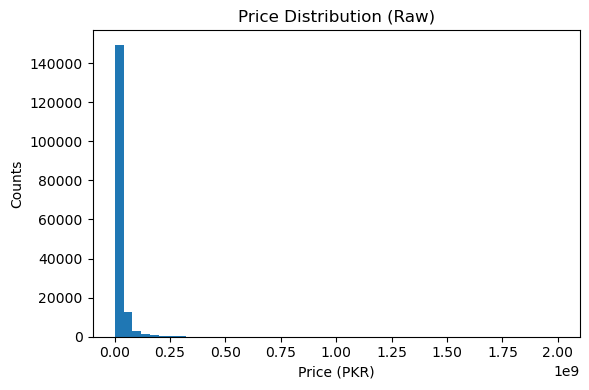

In [17]:
# Price distribution (raw)

plt.figure(figsize=(6,4))
plt.hist(df1["price"].dropna() , bins=50)
plt.title("Price Distribution (Raw)")
plt.xlabel("Price (PKR)")
plt.ylabel("Counts")
plt.tight_layout()
plt.show()

# ✅ Understanding `plt.tight_layout()` in Matplotlib

> Let’s focus on **this single line** from your code:

```python
plt.tight_layout()
````

---

## **What does it do?**

This line automatically adjusts all parts of the plot so that:

* **No labels get cut off** (e.g., X-axis or Y-axis text)
* **Title and chart don’t overlap**
* **Margins** (empty spaces) are appropriate
* The graph looks **clean, professional, and readable**

---

## **In your code context**

You created a histogram:

* Histogram: **Price Distribution**
* Small figure size: `figsize=(6, 4)` → plot takes limited space
* X-axis label: `"Price (PKR)"`
* Y-axis label: `"Count"`
* Title: `"Price Distribution (Raw)"`

Without `plt.tight_layout()`:

* Title may overlap with the histogram below
* Large numbers on the X-axis (e.g., `1,200,000`) may collide
* Y-axis label may be cut off

With `plt.tight_layout()`:

* Title moves slightly upward
* X and Y labels get proper space
* Histogram shrinks a bit and centers nicely

✅ Result: The plot becomes **“tight” (well-fitted) and well-spaced**, hence the name `tight_layout`.

---

## **Is it always necessary?**

Not always, but it’s **good practice**, especially when:

* Using a **small figure size**
* Labels are **long**
* Saving the plot for **reports or presentations**

---

## **Summary (Just this line)**

```python
plt.tight_layout()
```

* Automatically fits **title, labels, and chart** nicely
* Prevents **cut-off or overlapping** elements
* Makes your **histogram clean and professional**




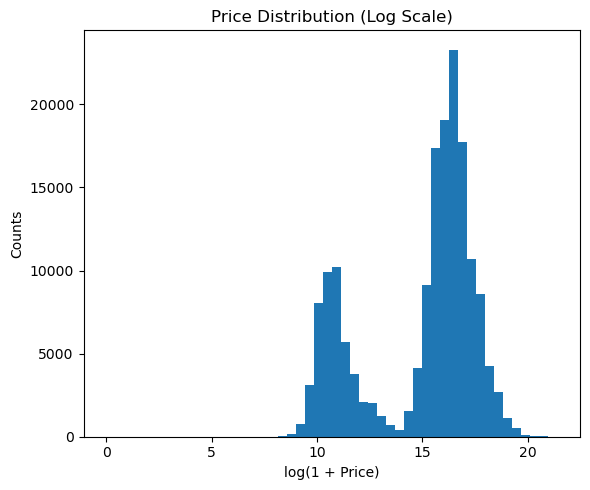

In [18]:
# Price distribution with log scale

df1["log_price"] = np.log1p(df1["price"])
plt.figure(figsize=(6,5))
plt.hist(df1["log_price"].dropna() , bins=50)
plt.xlabel("log(1 + Price)")
plt.ylabel("Counts")
plt.title("Price Distribution (Log Scale)")
plt.tight_layout()
plt.show()

## ✅ Understanding `df1["log_price"] = np.log1p(df1["price"])`

> Let’s focus on **this single line** from your code:

```python
df1["log_price"] = np.log1p(df1["price"])
````

---

## **What does this line do?**

* Creates a **new column** `log_price` in the DataFrame `df1`.
* Each value in this column is calculated as:

[
log_price = log(1 + price)
]

**Example**:

* If a house price = 850,000
* New value:

[
log(1 + 850000) = log(850001) ≈ 13.65
]

---

## **What is `np.log1p()`?**

* `np` → NumPy library
* `log1p(x)` → Shortcut for `log(1 + x)`

**Why use it?**

* Standard `log(0)` gives an error (`-∞`)
* `log1p(0) = log(1) = 0` → avoids errors
* Safe for **x = 0** or very small numbers

---

## **Why use it here?**

* House price data is often **highly skewed** (long tail).

* Example:

  * Most houses: 500,000 – 2,000,000
  * Some houses: 10,000,000+
  * Result: histogram shows **one short bell and one long tail**

* Skewed data is **hard for ML models**, especially **linear models**.

---

## **Benefits of taking log (logarithm)**

* Makes data more **symmetric / normal**
* **Compresses large values**
* Small values remain comparable
* Improves **model performance** and **stability**
* `log1p` ensures code works even if `price = 0`

---

## **In your code context**

* You plotted **histogram of `log_price`** instead of `price`
* This shows a **better distribution**
* If used as target in regression, `log_price` can improve predictions

---

## **When to use `np.log1p()`**

| Situation                                             | Use?                                         |
| ----------------------------------------------------- | -------------------------------------------- |
| Positive numeric data (price, income, distance, time) | ✅ Yes (especially if skewed)                 |
| Data contains zeros                                   | ✅ Yes, `log1p` is safe                       |
| Data is already normal                                | ❌ Not necessary                              |
| Negative values                                       | ❌ Not suitable — log works only on positives |

---

## **Summary**

```python
df1["log_price"] = np.log1p(df1["price"])
```

* Converts price data to **log scale**
* **Compresses large values**, keeps small values
* **Improves ML model performance**
* Safe for **zero values**
* Common technique in **regression problems**

---

💡 **Tip:** Log transformation is a standard, powerful technique in **data science**, especially for **regression with skewed target variables**.



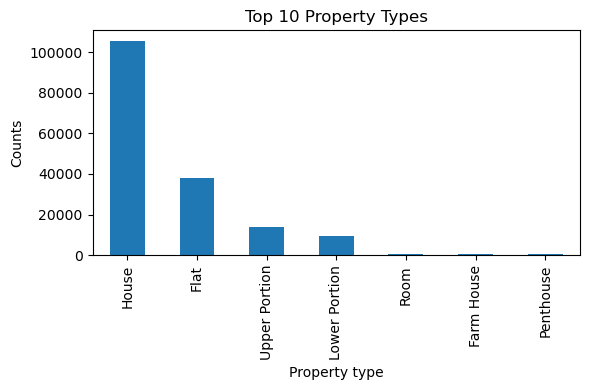

In [19]:
# Property type counts

plt.figure(figsize=(6,4))
type_counts = df1["property_type"].value_counts()
type_counts.head(10).plot(kind="bar")
plt.title("Top 10 Property Types")
plt.xlabel("Property type")
plt.ylabel("Counts")
plt.tight_layout()
plt.show()

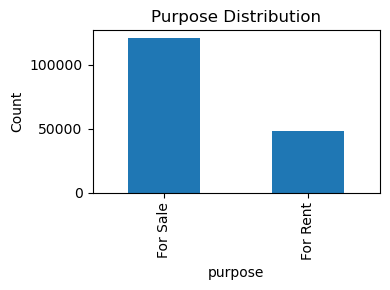

In [20]:
# Purpose counts (For Sale vs For Rent)

plt.figure(figsize=(4,3))
df1["purpose"].value_counts().plot(kind="bar")
plt.ylabel("Count")
plt.title("Purpose Distribution")
plt.tight_layout()
plt.show()

# 5 Supervised Learning I – Regression (Predict Price)

## 5.1 Prepare Data for Regression

We will create a smaller DataFrame df_reg with only the columns needed.

In [21]:
df1.columns

Index(['Unnamed: 0', 'property_id', 'location_id', 'page_url', 'property_type',
       'price', 'location', 'city', 'province_name', 'latitude', 'longitude',
       'baths', 'purpose', 'bedrooms', 'date_added', 'Total_Area',
       'log_price'],
      dtype='object')

In [22]:
# Select relevant columns
cols_reg = ["price" , "bedrooms" , "baths"  , "Total_Area"  , "city"  , "property_type"]
df_reg = df1[cols_reg].copy()
df_reg

,price,bedrooms,baths,Total_Area,city,property_type
0,10000000,2,2,1089.004,Islamabad,Flat
1,6900000,3,3,15246.056,Islamabad,Flat
2,16500000,5,6,2178.008,Islamabad,House
3,43500000,4,4,10890.000,Islamabad,House
4,7000000,3,3,2178.008,Islamabad,House
...,...,...,...,...,...,...
168441,26500000,6,0,26136.096,Karachi,House
168442,12500000,3,0,2178.008,Karachi,House
168443,27000000,6,0,26136.096,Karachi,House
168444,11000000,3,0,21235.578,Karachi,House


In [ ]:
# Drop rows with missing values
df_reg = df_reg.dropna()

# Remove rows where Total_Area is zero or negative
df_reg = df_reg[df_reg["Total_Area"] > 0]

# Optional: feature - price per unit area
df_reg["price_per_unit_area"] = df_reg["price"] / df_reg["Total_Area"]



In [ ]:
df_reg.shape

In [ ]:
df_reg.head()


## 5.2 Encode Categorical Features

In [ ]:
df_reg_encode = pd.get_dummies(df_reg , columns=["city" , "property_type"] , drop_first=True)
df_reg_encode

# ✅ Understanding `drop_first=True` in `pd.get_dummies()`

> Your code line:

```python
df_reg_encode = pd.get_dummies(df_reg, columns=["city", "property_type"], drop_first=True)
````

---

## **What does `drop_first=True` do?**

* When using `pd.get_dummies()`, **a new binary column** (0 or 1) is created for **each unique category**.

**Example**:

* Column `"city"` has 3 values: `["Karachi", "Lahore", "Islamabad"]`
* Normally, this creates **three columns**:

```
city_Karachi
city_Lahore
city_Islamabad
```

* With `drop_first=True`, the **first category is dropped**:

```
city_Lahore
city_Islamabad
```

* `city_Karachi` is left out as the **reference category**.

---

## **Why is this important?**

* **Prevents Multicollinearity** (also called **Dummy Variable Trap**)

### 🔹 What is Multicollinearity?

* Occurs when **features are perfectly dependent** on each other
* Example:

```
city_Karachi + city_Lahore + city_Islamabad = 1
```

* Knowing two columns automatically gives the third.
* This can **confuse linear models**, affect coefficients, and make matrix computations unstable.

---

## **Effect on the model**

* Linear Regression, Logistic Regression, or other models using **matrix inversion** can fail or misinterpret the coefficients.
* Redundant columns **increase complexity** without adding information.

---

## **Why `drop_first=True` is used here**

* Your code is preparing **categorical features** for a **regression model**: `"city"` and `"property_type"`.

* Without `drop_first=True`, you get **redundant columns**, which can:

  * Mislead the model
  * Increase unnecessary complexity

* With `drop_first=True`:

  * One reference category per feature is dropped
  * Information is preserved
  * Model becomes **stable and free of multicollinearity**

---

## **Example**

### Original Data:

| city    |
| ------- |
| Karachi |
| Lahore  |
| Karachi |

### Without `drop_first`:

| city_Karachi | city_Lahore |
| ------------ | ----------- |
| 1            | 0           |
| 0            | 1           |
| 1            | 0           |

* Works, but if a third class existed (Islamabad), you would have **3 columns = redundant info**

### With `drop_first=True`:

| city_Lahore | city_Islamabad |
| ----------- | -------------- |
| 0           | 0              |
| 1           | 0              |
| 0           | 0              |

* If both new columns = 0 → automatically **Karachi (reference class)**
* ✅ Preserves information, removes redundancy

> **Note**: `drop_first` usually drops the **alphabetically first category** (e.g., Karachi).

---

## **When to use `drop_first=True`**

| Situation                                 | Recommended?                                        |
| ----------------------------------------- | --------------------------------------------------- |
| Linear / Logistic Regression              | ✅ Always                                            |
| Random Forest, XGBoost                    | ❌ Not necessary (not affected by multicollinearity) |
| Data for EDA only                         | ❌ Not necessary (want all columns)                  |
| Need all category columns for explanation | ❌ Not necessary                                     |

---

## **Summary**

* `drop_first=True`:

  * Drops the **first/reference category** in one-hot encoding
  * **Prevents multicollinearity / Dummy Variable Trap**
  * **Essential for linear models**, optional for tree-based models
  * Keeps features **independent and stable**

> In your code, it ensures your regression model gets **clean, non-redundant features** for training. 😊


In [ ]:
X_reg = df_reg_encode.drop(columns=["price"])
y_reg = df_reg_encode["price"]

## 5.3 Train–Test Split and Model Training

In [ ]:
X_train , X_test , y_train , y_test = train_test_split(
    X_reg , y_reg ,  test_size = 0.2 , random_state=42
)

reg_model = LinearRegression()
reg_model.fit(X_train , y_train)

## 5.4 Evaluate Regression Model

In [ ]:
y_pred_reg = reg_model.predict(X_test)

 
# ✅ Understanding `reg_model.predict(X_test_reg)`

> Your code line:

```python
y_pred_reg = reg_model.predict(X_test_reg)
````

---

## **What does it do?**

* Runs the **trained regression model** on the **test data** (`X_test_reg`)
* Produces **predicted values** (`y_pred_reg`) for each row in the test set

**In other words**:

> "Look at the input features (area, bedrooms, etc.) and predict the likely price."

---

## **Why is it used?**

* To evaluate how the model performs on **new, unseen data**
* This simulates **real-world predictions**, since in practice we don’t know the true target values

---

## **When to use it?**

* After you have **trained your model** on the training set
* Use it on **test data only**

  * ❌ Don’t use on training data (otherwise overfitting won’t be visible)
* Anytime you want to **make predictions on new inputs**

---

### **Key takeaway**

* `.predict()` is the method that **turns a trained model into actionable predictions**
* For regression models, it outputs **continuous numeric values** (like prices)
* For classification models, it outputs **class labels** (like High/Low)
 


In [ ]:
r2 = r2_score(y_test , y_pred_reg)
print("R2 score : "  , r2)

 
# ✅ Understanding `r2_score(y_test_reg, y_pred_reg)`

> Your code line:

```python
r2 = r2_score(y_test_reg, y_pred_reg)
````

---

## **What does it do?**

* Calculates the **R² (R-squared) score**, a metric for regression model performance
* Compares the **true values** (`y_test_reg`) with the **predicted values** (`y_pred_reg`)

---

## **What does R² tell us?**

| R² Value      | Meaning                                           |
| ------------- | ------------------------------------------------- |
| 1.0           | Perfect predictions — model explains all variance |
| 0.0           | Model only predicts the mean — learned nothing    |
| Negative (<0) | Model performs worse than predicting the mean     |

**Example**:
R² = 0.75 → Model explains **75% of the variance** in house prices

---

## **Why is it used?**

* It’s the **most common and easy-to-understand performance metric** for regression models
* Tells us how well the model **explains the variation in the target**

---

## **When to use it?**

* Only for **regression problems**
* On the **test set** (not training set) to avoid overfitting bias
* Whenever you want to measure a model’s **explanatory power**

---

### **Note**

* `r2_score(y_true, y_pred)` → **first argument** is true values, **second argument** is predicted values


In [ ]:
# Optional: simple scatter of actual vs predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test , y_pred_reg , alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# 6 Supervised Learning II – Classification (Sale vs Rent)

### 6.1 Prepare Data for Classification

In [ ]:
# Columns for classifications

cols_clf = ["purpose", "bedrooms", "baths", "Total_Area", "price"]
df_clf = df1[cols_clf].copy()
df_clf.head()

In [ ]:
# Drop missing columns
df_clf = df_clf.dropna()

In [ ]:
# Encode purpose (For Sale / For Rent) as 0/1
le = LabelEncoder()
df_clf["prupose_label"] = le.fit_transform(df_clf["purpose"])
df_clf.head()

# 6.2 Train Classification Model


In [ ]:
feature_cols = ["bedrooms" , "baths" , "Total_Area" , "price"]
X_clf = df_clf[feature_cols]
y_clf = df_clf["prupose_label"]

In [ ]:
X_train , X_test , y_train , y_test = train_test_split(
    X_clf , y_clf , test_size=0.2  , random_state=42
)

In [ ]:
clf_model = RandomForestClassifier(n_estimators=100 , random_state=42)
clf_model.fit(X_train , y_train)

# 6.3 Evaluate Classification Model

In [ ]:
y_pred_clf  = clf_model.predict(X_test)

acc = accuracy_score(y_test , y_pred_clf)
cm = confusion_matrix(y_test , y_pred_clf)

print("Accuracy:", acc)
print("Confusion Matrix:")
print(cm)

#  7 Lab Tasks – 2 Hour Plan

## 🔹 Task 1 – Dataset Exploration (EDA)

- Print shape, first 10 rows, and last 10 rows of df.
- Use df.isna().sum() to check missing values.
- Plot:
  - Histogram of price (raw).
  - Histogram of log_price.
  - Bar chart of property_type counts.
  - Bar chart of purpose (For Sale / For Rent).
- In a markdown cell, write 3 bullet points:

In [ ]:
df.shape

In [ ]:
df.head(10)

In [ ]:
df.tail(10)

In [ ]:
df.isnull().sum()

In [ ]:
# Histogram of price (raw)
plt.hist(df["price"].dropna() , bins=50)
plt.title("Price Distribution (Raw)")
plt.xlabel("Price")
plt.ylabel("Counts")
plt.tight_layout()
plt.show()

In [ ]:
# Histogram of log_price
plt.figure(figsize=(6,4))
plt.hist(df1["log_price"].dropna() , bins=50)
plt.title("Log Price Distribution (Raw)")
plt.xlabel("Price")
plt.ylabel("Counts")
plt.tight_layout()
plt.show()

In [ ]:
# Bar chart of property_type counts

df1["property_type"].value_counts().plot(kind="bar")
plt.title("Property typer Counts")
plt.ylabel("Counts")
plt.tight_layout()
plt.show()


In [ ]:
# Bar chart of purpose (For Sale / For Rent)

plt.figure(figsize=(4,4))
df1["purpose"].value_counts().plot(kind="bar")
plt.title("Chart of purpose (For Sale / For Rent)")
plt.ylabel("Counts")
plt.tight_layout()
plt.show()

- The price distribution is highly right-skewed, with most properties concentrated at lower prices and a long tail of high-priced outliers; applying log transformation makes the distribution more symmetric and suitable for modeling.  
- "House" is the most common property type by far, while other types (e.g., "Flat", "Upper Portion") appear significantly less frequent.  
- There are far more properties listed "For Sale" than "For Rent", indicating a stronger representation of sale transactions in the dataset.

# 🔹 Task 2 – Data Cleaning & Feature Engineering

- Create df_reg with columns price, bedrooms, baths, Total_Area, city, property_type.
- Drop rows with missing values and with zero/negative Total_Area.
- Create price_per_area feature.
- Encode city and property_type using pd.get_dummies.
- Print df_reg_encoded.shape and df_reg_encoded.head().

In [ ]:
cols = ["price", "bedrooms" , "baths" , "Total_Area" , "city" , "property_type"]
df = df[cols].copy()
df

In [ ]:
# Drop rows with missing values and with zero/negative Total_Area.
df["Total_Area"].dropna()

df = df[df["Total_Area"] > 0]
df["Total_Area"]

In [ ]:
# Create price_per_area feature.

df["price_per_area"] = df["price"] / df["Total_Area"]
# df["price_per_area"] 

In [ ]:
# Encode city and property_type using pd.get_dummies

df_reg_encode = pd.get_dummies(df , columns = ["city" , "property_type"] , drop_first=True)
df_reg_encode

In [ ]:
# Print df_reg_encoded.shape and df_reg_encoded.head()

df_reg_encode.shape


In [ ]:
df_reg_encode.head()

# 🔹 Task 3 – Regression Model (Predict Price)

- Split data into train and test sets (80/20 split).
- Train a LinearRegression model.
- Predict on test set and compute R².
- Plot Actual vs Predicted price.
- In markdown, write a short comment: Is the model good enough? Why or why not?

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score , accuracy_score , confusion_matrix

In [ ]:
X_reg  =  df_reg_encode.drop(columns=["price"])
y_reg =  df_reg_encode["price"]

In [ ]:
X_train , X_test , y_train , y_test = train_test_split(
    X_reg , y_reg ,  test_size = 0.2 , random_state=42
)

reg_model = LinearRegression()
reg_model.fit(X_train , y_train)

In [ ]:
y_pred_reg = reg_model.predict(X_test)

In [ ]:
r2 = r2_score(y_test , y_pred_reg)

In [ ]:
print("R2 Score : " , r2)

In [ ]:
# Plot Actual vs Predicted price

plt.scatter(y_test , y_pred_reg , alpha=0.3)
plt.title("Plot actual vs Predicted price")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.tight_layout()
plt.grid(True)
plt.show()


# 🔹 Task 4 – Classification Model (Sale vs Rent)

- Create df_clf with purpose, bedrooms, baths, Total_Area, price.
- Encode purpose as 0/1 using LabelEncoder.
- Train RandomForestClassifier on these features.
- Compute accuracy and show confusion matrix.

In [ ]:
cols = ["purpose", "bedrooms", "baths", "Total_Area", "price"]
df_clf = df1[cols].copy()
df_clf.dropna()
df_clf

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()


In [ ]:
df_clf["purpose_label"] = le.fit_transform(df_clf["purpose"])

In [ ]:
df_clf

In [ ]:
feature_cols = ["bedrooms" , "baths" , "Total_Area" , "price"]
X_clf = df_clf[feature_cols]
y_clf = df_clf["purpose_label"]

In [ ]:
X_train , X_test , y_train , y_test = train_test_split(
    X_clf , y_clf , test_size=0.2  , random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
clf_model = RandomForestClassifier()

In [ ]:
clf_model.fit(X_train , y_train)

In [ ]:
y_pred_clf = clf_model.predict(X_test)

In [ ]:
acc = accuracy_score(y_test , y_pred_clf)

In [ ]:
cm = confusion_matrix(y_test  , y_pred_clf)

In [ ]:
print("Accuracy:", acc)
print("Confusion Matrix:")
print(cm)

# 9 Homework – Model Improvement

At home, extend your notebook with the following:

1. For regression, try a second model:
   
  - RandomForestRegressor or DecisionTreeRegressor (you will need to import them).
   
2. Train and evaluate the new regression model on the same train/test split.
3. Compare R² of LinearRegression vs the new model.
4. For classification, try changing n_estimators in RandomForestClassifier and observe how accuracy changes.

In [ ]:
#  Using this RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor


In [ ]:
X_train , X_test , y_train , y_test = train_test_split(
    X_reg , y_reg , test_size=0.2 , random_state=42
)

In [ ]:
model_1 = RandomForestRegressor()

In [ ]:
model_1.fit(X_train  , y_train)

In [ ]:
y_pred_reg = model_1.predict(X_test)

In [ ]:
r2 = r2_score(y_pred_reg , y_test)

In [ ]:
print("R2 score : ", r2)
print("Good")

In [ ]:
#  Using this DecisionTreeRegressor
from sklearn.tree import DecisionTreeRegressor

In [ ]:
model_2 = DecisionTreeRegressor()

In [ ]:
model_2.fit(X_train , y_train)

In [ ]:
y_pred_reg2 = model_2.predict(X_test)

In [ ]:
r2 = r2_score(y_pred_reg2 , y_test)

In [ ]:
print("R2 score : " , r2)

In [ ]:
# For classification, try changing n_estimators in RandomForestClassifier and observe how accuracy changes.

# Encode purpose (For Sale / For Rent) as 0/1
le = LabelEncoder()
df_clf["prupose_label"] = le.fit_transform(df_clf["purpose"])
df_clf.head()

feature_cols = ["bedrooms" , "baths" , "Total_Area" , "price"]
X_clf = df_clf[feature_cols]
y_clf = df_clf["prupose_label"]

X_train , X_test , y_train , y_test = train_test_split(
    X_clf , y_clf , test_size=0.2  , random_state=42
)

clf_model = RandomForestClassifier(n_estimators=100 , random_state=42)
clf_model.fit(X_train , y_train)

y_pred_clf  = clf_model.predict(X_test)

acc = accuracy_score(y_test , y_pred_clf)
cm = confusion_matrix(y_test , y_pred_clf)

print("Accuracy:", acc)
print("Confusion Matrix:")
print(cm)

In [ ]:
clf_model = RandomForestClassifier(n_estimators=50 , random_state=42)
clf_model.fit(X_train , y_train)

y_pred_clf  = clf_model.predict(X_test)

acc = accuracy_score(y_test , y_pred_clf)
cm = confusion_matrix(y_test , y_pred_clf)

print("Accuracy:", acc)
print("Confusion Matrix:")
print(cm)

In [ ]:
clf_model = RandomForestClassifier(n_estimators=10 , random_state=42)
clf_model.fit(X_train , y_train)

y_pred_clf  = clf_model.predict(X_test)

acc = accuracy_score(y_test , y_pred_clf)
cm = confusion_matrix(y_test , y_pred_clf)

print("Accuracy:", acc)
print("Confusion Matrix:")
print(cm)

In [ ]:
clf_model = RandomForestClassifier(n_estimators=200 , random_state=42)
clf_model.fit(X_train , y_train)

y_pred_clf  = clf_model.predict(X_test)

acc = accuracy_score(y_test , y_pred_clf)
cm = confusion_matrix(y_test , y_pred_clf)

print("Accuracy:", acc)
print("Confusion Matrix:")
print(cm)

In [ ]:
clf_model = RandomForestClassifier(n_estimators=100000000 , random_state=42)
clf_model.fit(X_train , y_train)

y_pred_clf  = clf_model.predict(X_test)

acc = accuracy_score(y_test , y_pred_clf)
cm = confusion_matrix(y_test , y_pred_clf)

print("Accuracy:", acc)
print("Confusion Matrix:")
print(cm)